# ELM corpus: charge exchange to the isobaric analog state

$(p,n)$ scattering to the isobaric analog state of the target ground state. The analog
state is the isospin partner of the ground state, so this transition constrains the
isovector part of the optical potential in a way elastic scattering alone does not.

Selecting it is the whole difficulty. The analog state is picked out by a window on the
residual excitation energy, but EXFOR entries report that energy inconsistently -- some
give an excitation energy, some a Q value, some a level or analog-state number, and some
nothing at all. Entries that fall outside the window for those reasons are re-added
below, one at a time, on explicit grounds.

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt

import numpy as np
from periodictable import elements

from nn_corpora import elm, elm_curate, munge, plotting, serialize, spec

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## Targets

The near-spherical targets of the elastic sectors, further restricted to those with a
tabulated analog-state excitation energy.

In [2]:
targets = spec.elm_pn_targets()
for A, Z in sorted(targets, key=lambda t: (t[1], t[0])):
    print(f"  {A}{elements[Z].symbol:<3s}  E_IAS = {spec.ELM_EX_IAS[(A, Z)]:8.4f} MeV")

  48Ca   E_IAS =   6.6775 MeV
  64Ni   E_IAS =   6.8100 MeV
  90Zr   E_IAS =   5.0080 MeV
  92Zr   E_IAS =   9.0080 MeV
  96Zr   E_IAS =  11.0300 MeV
  92Mo   E_IAS =   3.8130 MeV
  116Sn   E_IAS =   8.3742 MeV
  118Sn   E_IAS =   9.2890 MeV
  120Sn   E_IAS =  10.2040 MeV
  124Sn   E_IAS =  12.2007 MeV
  208Pb   E_IAS =  15.1640 MeV


## Query

The excitation-energy window is $\pm$ 0.3 MeV about the tabulated analog state. Unlike
the elastic sectors there is no minimum point count: analog-state angular distributions
are sparse, sometimes only a few angles.

In [3]:
pn = elm_curate.query_pn(
    targets,
    einc_range=spec.ELM_PN_EINC_RANGE,
    ias_window=spec.ELM_IAS_WINDOW,
)
for target, multi in sorted(pn.items()):
    entries = multi.data["dXS/dA"]
    print(f"{target}: {len(entries.entries)} parsed, {len(entries.failed_parses)} failed")

(48, 20): 1 parsed, 1 failed
(64, 28): 1 parsed, 0 failed
(90, 40): 2 parsed, 0 failed
(92, 40): 1 parsed, 0 failed
(92, 42): 0 parsed, 0 failed
(96, 40): 1 parsed, 0 failed
(116, 50): 2 parsed, 0 failed
(118, 50): 1 parsed, 0 failed
(120, 50): 3 parsed, 0 failed
(124, 50): 1 parsed, 0 failed
(208, 82): 1 parsed, 1 failed


## Repair failed parses

In [4]:
result = elm_curate.ElmSectorResult(sector="charge_exchange")
elm_curate.repair_failed_parses(pn, ("dXS/dA",), result)
print("\n".join(sorted(set(result.repaired))) or "nothing to repair")

dXS/dA C0134 via ('ERR-S',)


## Entries the excitation-energy window rejects

`O0178` reports the analog state by analog-state number rather than excitation energy,
so it never falls inside any window; it is re-added with no excitation-energy
restriction. `D0049` (Carlson) is older and reports the analog state energy differently
from modern compilations, so its window is widened to $\pm$ 0.5 MeV. `O0090` (Batty)
reports lab-frame angles, converted to the CM frame below. `O0138` reports asymmetric
$\pm$`ERR-T` uncertainties.

In [5]:
for target in [(48, 20), (208, 82), (120, 50), (90, 40)]:
    if target in pn:
        elm_curate.readd_entry(
            pn, target, "O0178", result,
            einc_range=spec.ELM_PN_EINC_RANGE,
            parsing_kwargs=elm.PARSE_RECIPES["O0178"].parsing_kwargs,
            reason="reports the analog state by analog-state number, not excitation energy",
        )

for target in [(208, 82), (118, 50), (120, 50), (90, 40)]:
    if target in pn:
        ex = spec.ELM_EX_IAS[target]
        elm_curate.readd_entry(
            pn, target, "D0049", result,
            einc_range=spec.ELM_PN_EINC_RANGE,
            ex_range=(ex - elm.WIDE_IAS_WINDOW, ex + elm.WIDE_IAS_WINDOW),
            reason=elm.WIDE_IAS_WINDOW_ENTRIES["D0049"],
        )

for target in [(116, 50), (124, 50)]:
    if target in pn:
        elm_curate.readd_entry(
            pn, target, "O0138", result,
            einc_range=spec.ELM_PN_EINC_RANGE,
            parsing_kwargs=elm.PARSE_RECIPES["O0138"].parsing_kwargs,
            reason="reports asymmetric +/-ERR-T uncertainties",
        )

print("\n".join(result.repaired))

dXS/dA C0134 via ('ERR-S',)
O0178 re-added for 48/20: reports the analog state by analog-state number, not excitation energy
O0178 re-added for 208/82: reports the analog state by analog-state number, not excitation energy
O0178 re-added for 120/50: reports the analog state by analog-state number, not excitation energy
O0178 re-added for 90/40: reports the analog state by analog-state number, not excitation energy
D0049 re-added for 208/82: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
D0049 re-added for 118/50: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
D0049 re-added for 120/50: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
D0049 re-added for 90/40: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
O0138 re-added 

### Lab-frame angles

`O0090` (Batty et al.) reports lab-frame angles. It is re-added with the frame filter
off and converted here; the conversion is exact for two-body kinematics with the
projectile lighter than the target.

In [6]:
for target in [(208, 82), (120, 50)]:
    if target not in pn:
        continue
    elm_curate.readd_entry(
        pn, target, "O0090", result,
        einc_range=spec.ELM_PN_EINC_RANGE,
        parsing_kwargs=elm.PARSE_RECIPES["O0090"].parsing_kwargs,
        reason=elm.LAB_ANGLE_ENTRIES["O0090"],
    )
    entry = pn[target].data["dXS/dA"].entries.get("O0090")
    if entry is not None:
        elm_curate.convert_lab_angles(entry, target, spec.PROJECTILES["proton"])
        print(f"{target}: converted O0090 to CM angles")

(208, 82): converted O0090 to CM angles


(120, 50): converted O0090 to CM angles


## Exclusions and duplicate measurements

`T0162` is dominated by Gamow-Teller strength rather than the analog-state transition.
`E1667` carries a duplicate empty measurement ahead of the real one.

In [7]:
elm_curate.exclude_entries(pn, "dXS/dA", elm.EXCLUDED_PN, result)

for entry_id, index, reason in elm.MEASUREMENT_DROPS:
    for target, multi in pn.items():
        entry = multi.data["dXS/dA"].entries.get(entry_id)
        if entry is not None and len(entry.measurements) > index + 1:
            del entry.measurements[index]
            result.excluded.append(f"{entry_id} measurement {index}: {reason}")

print("\n".join(sorted(set(result.excluded))) or "no exclusions applied")

E1667 measurement 0: duplicate/blank measurement within the entry
dXS/dA T0162: dominated by Gamow-Teller strength, not the isobaric analog state


## Missing uncertainties

`C0134` reports no uncertainty for several points. Figure 5 of Phys. Rev. C 31 (1985)
1147 shows the markers there are larger than the error bars, and the last point without
an error has a value close to the first point with one. The missing uncertainties are
therefore set, conservatively, to about the size of the first reported one.

In [8]:
elm_curate.apply_uncertainty_patches(pn, result)
print("\n".join(sorted(set(result.repaired))))

C0134004: missing uncertainties set to the size of the first reported one, read from Fig. 5 of Phys. Rev. C 31 (1985) 1147
D0049 re-added for 118/50: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
D0049 re-added for 120/50: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
D0049 re-added for 208/82: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
D0049 re-added for 90/40: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
O0090 re-added for 120/50: Batty et al. report lab-frame angles
O0090 re-added for 208/82: Batty et al. report lab-frame angles
O0138 re-added for 116/50: reports asymmetric +/-ERR-T uncertainties
O0138 re-added for 124/50: reports asymmetric +/-ERR-T uncertainties
O0178 re-added for 120/50: reports the analo

## Munge and serialize

In [9]:
elm_curate.finalize(pn, "charge_exchange", "proton", result)
print(result.summary())

elm/charge_exchange
  targets                0
  measurements           30
  data points            622
  excluded
    dXS/dA T0162: dominated by Gamow-Teller strength, not the isobaric analog state
    E1667 measurement 0: duplicate/blank measurement within the entry
  repaired
    dXS/dA C0134 via ('ERR-S',)
    O0178 re-added for 48/20: reports the analog state by analog-state number, not excitation energy
    O0178 re-added for 208/82: reports the analog state by analog-state number, not excitation energy
    O0178 re-added for 120/50: reports the analog state by analog-state number, not excitation energy
    O0178 re-added for 90/40: reports the analog state by analog-state number, not excitation energy
    D0049 re-added for 208/82: Carlson data are older and report the isobaric analog state excitation energy differently from modern compilations
    D0049 re-added for 118/50: Carlson data are older and report the isobaric analog state excitation energy differently from modern com

## Inspect

Every parsed data set is plotted, one figure per target, grouped by incident energy and
offset for legibility. This is the view the corrections above were made from, so nothing
is sampled or truncated: the count of plotted data sets is checked against the number
written below, because a data set that is never drawn is one whose outliers are never
found.

plotted all 30 data sets


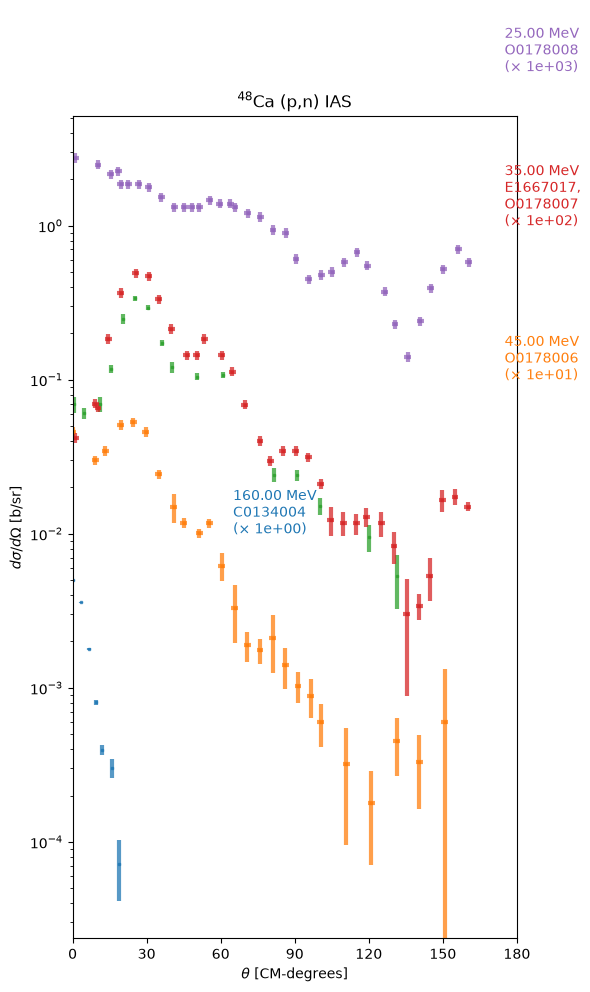

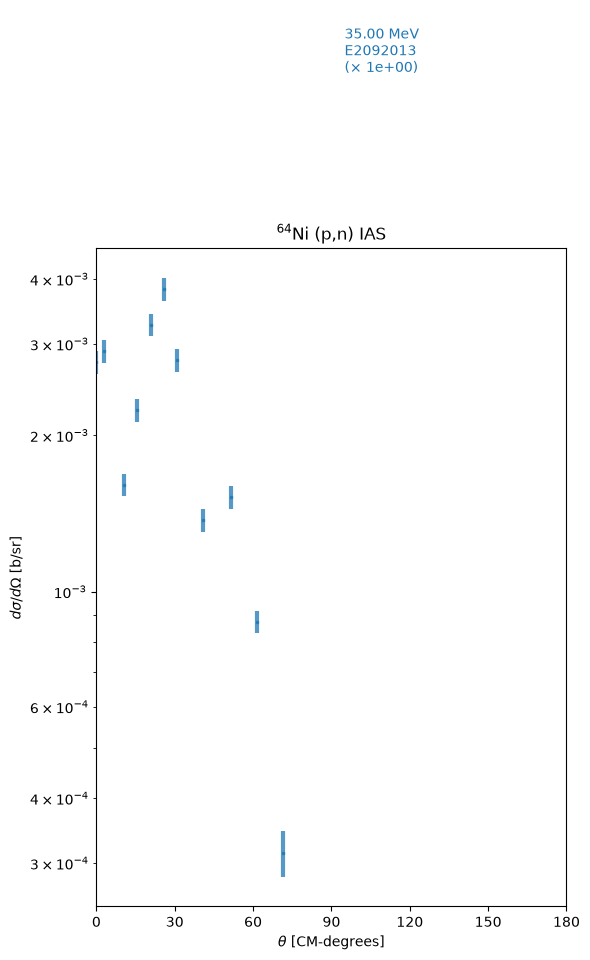

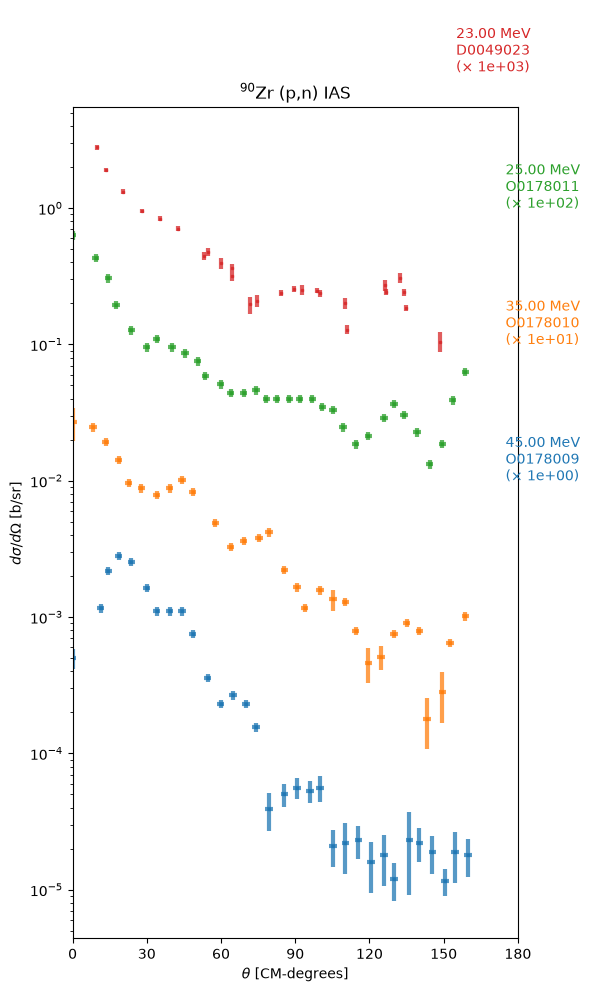

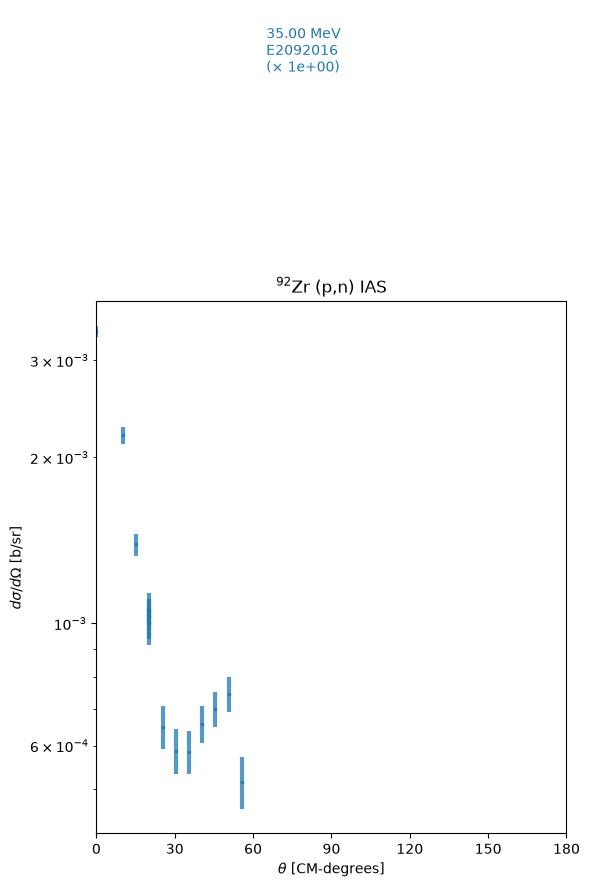

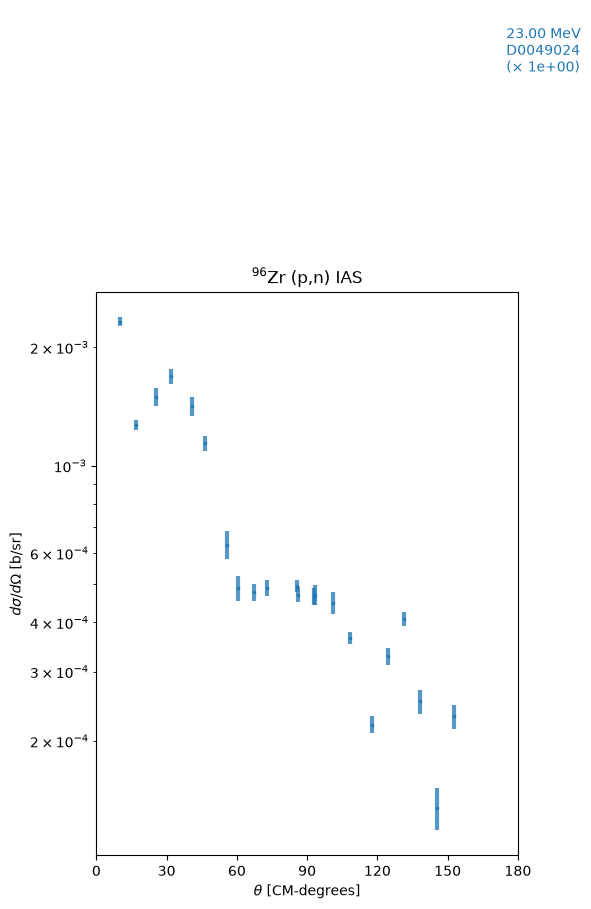

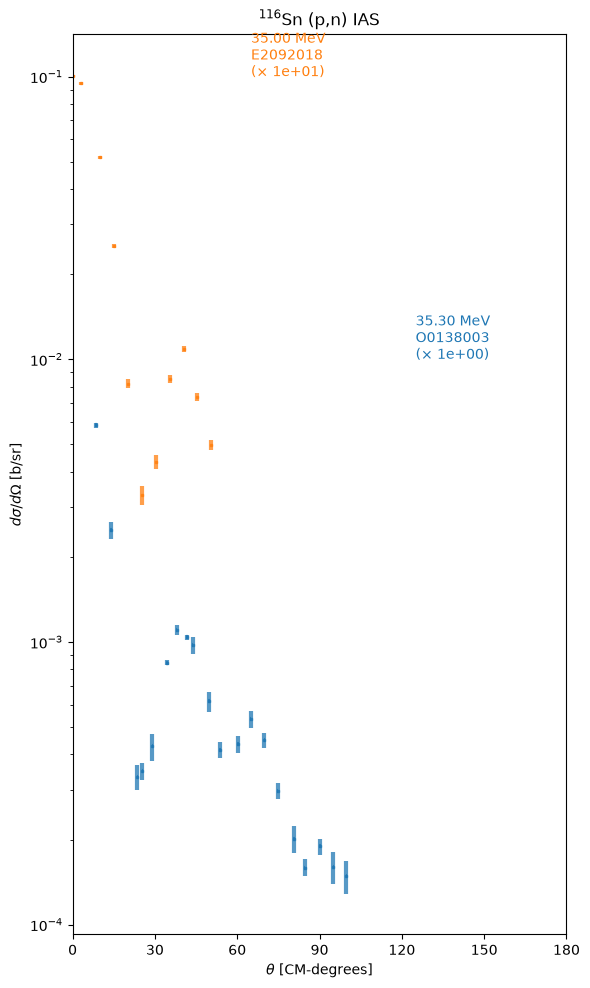

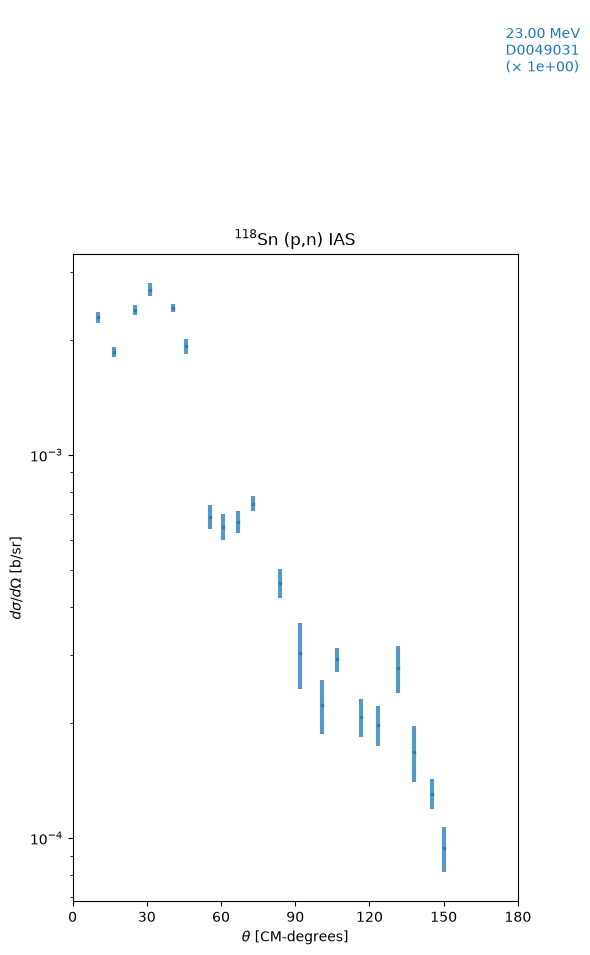

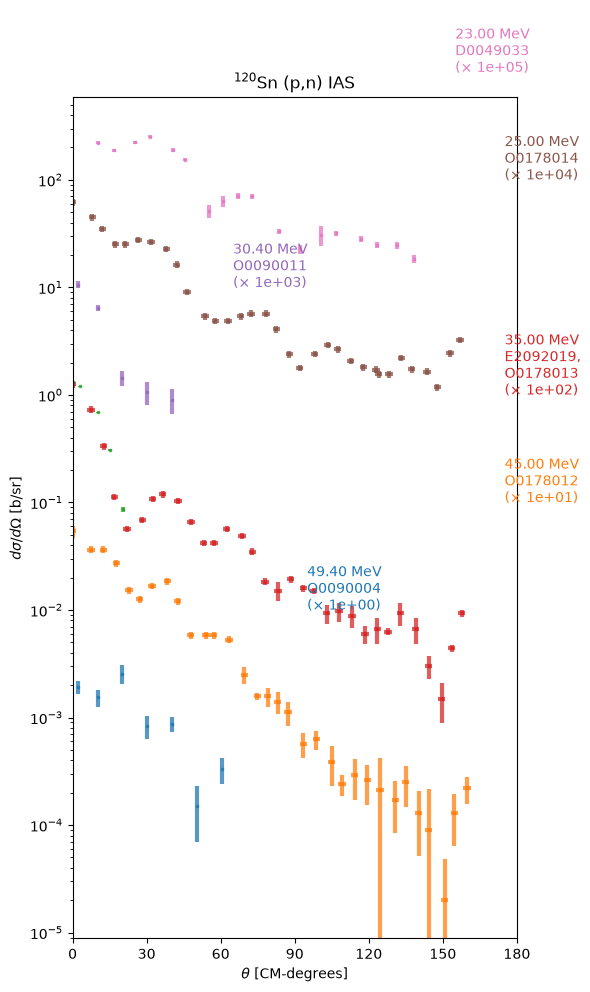

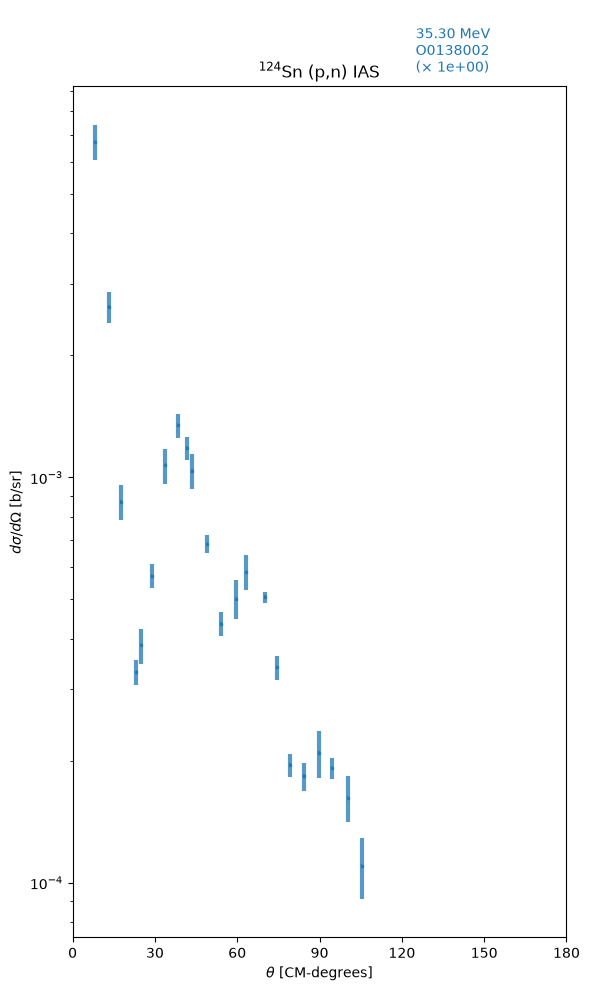

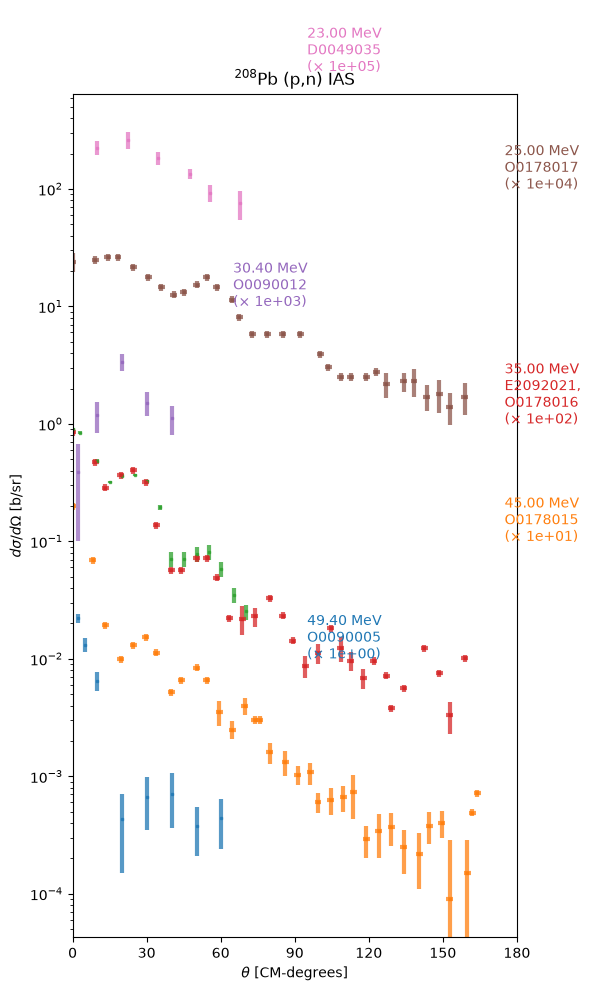

In [10]:
n_plotted = plotting.plot_multi(pn, label="(p,n) IAS", n_per_plot=6)
assert n_plotted == len(result.records), (
    f"{len(result.records) - n_plotted} of {len(result.records)} data sets were not plotted")
print(f"plotted all {n_plotted} data sets")
plt.show()

## Write

In [11]:
serialize.write_sector(result.records, corpus="elm", sector="charge_exchange",
                       bibtex=result.bibtex)
print(f"wrote {len(result.records)} measurements to data/elm/charge_exchange/")


wrote 30 measurements to data/elm/charge_exchange/
